# Battery-Constrained Planetary Rover Experimental Study

## Research question

**How do onboard memory capacity, the number of scientific datasets, and time-dependent data degradation affect the feasibility, efficiency, and computational difficulty of battery-constrained planetary-rover plans generated with PDDL+?**

This notebook analyses the final experiment conducted on unseen seeds after the model parameters were frozen.

### Experimental design

- Dataset count: 2, 3, and 4
- Memory level: low, medium, and high
- Corruption level: low, medium, and high
- Final evaluation seeds: 10–14
- Battery capacity: 40 energy units
- Terrain-dependent travel time and movement-energy cost
- Planner: ENHSP with `sat-hadd`
- Standard computational budget: 30 seconds per instance
- Selective classification budget: 120 seconds only for standard timeouts
- Total final instances: 135

The standard results are used for planner-runtime analysis. The classified results are used for mission-feasibility analysis.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, friedmanchisquare, kruskal

warnings.filterwarnings("ignore", category=FutureWarning)

DATASET_ORDER = [2, 3, 4]
MEMORY_ORDER = ["low", "medium", "high"]
CORRUPTION_ORDER = ["low", "medium", "high"]
STANDARD_STATUS_ORDER = ["solved", "unsolvable", "timeout"]
CLASSIFICATION_STATUS_ORDER = ["solved", "unsolvable"]


def find_project_root(start: Path) -> Path:
    """Locate the repository from JupyterLab or a terminal launch directory."""
    resolved = start.resolve()
    candidates = [resolved, *resolved.parents]

    for candidate in candidates:
        expected = (
            candidate
            / "experiments"
            / "results"
            / "battery_final_unseen.csv"
        )
        if expected.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository. Start JupyterLab from the "
        "project folder or one of its subdirectories."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

STANDARD_RESULTS_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "battery_final_unseen.csv"
)

CLASSIFIED_RESULTS_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "battery_final_unseen_classified.csv"
)

PLOT_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "plots"
    / "battery_final"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "tables"
    / "battery_final"
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project paths configured successfully.")

Project paths configured successfully.


## 1. Load and validate the final experiment

Two result files are intentionally retained:

- `battery_final_unseen.csv` contains the original 30-second planner outcomes.
- `battery_final_unseen_classified.csv` preserves those standard outcomes and adds the selective 120-second classifications for the three standard timeouts.

Extended runtimes must not replace standard runtimes in computational comparisons because only the difficult timeout instances received the larger budget.

In [2]:
standard_df = pd.read_csv(STANDARD_RESULTS_PATH)
classified_df = pd.read_csv(CLASSIFIED_RESULTS_PATH)

numeric_columns = [
    "seed",
    "dataset_count",
    "memory_ratio",
    "memory_capacity",
    "total_dataset_size",
    "memory_utilization_ratio",
    "average_travel_time_per_edge",
    "total_one_way_travel_time",
    "optimistic_minimum_energy",
    "battery_capacity",
    "battery_headroom",
    "safe_dataset_count",
    "unsafe_dataset_count",
    "timeout_seconds",
    "wall_runtime_seconds",
    "reported_plan_length",
    "reported_elapsed_time",
    "plan_makespan",
    "travel_time_in_plan",
    "estimated_travel_time",
    "stationary_time",
    "energy_used",
    "battery_remaining",
    "battery_utilization_ratio",
    "action_count",
    "move_actions",
    "collect_actions",
    "offload_actions",
    "waiting_periods",
    "total_waiting_time",
    "standard_runtime_seconds",
    "classification_runtime_seconds",
]

for frame in [standard_df, classified_df]:
    for column in numeric_columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(
                frame[column],
                errors="coerce",
            )

for frame in [standard_df, classified_df]:
    frame["dataset_count"] = frame["dataset_count"].astype(int)
    frame["seed"] = frame["seed"].astype(int)
    frame["memory_level"] = pd.Categorical(
        frame["memory_level"],
        categories=MEMORY_ORDER,
        ordered=True,
    )
    frame["corruption_level"] = pd.Categorical(
        frame["corruption_level"],
        categories=CORRUPTION_ORDER,
        ordered=True,
    )

classified_df["standard_status"] = pd.Categorical(
    classified_df["standard_status"],
    categories=STANDARD_STATUS_ORDER,
    ordered=True,
)

classified_df["classification_status"] = pd.Categorical(
    classified_df["classification_status"],
    categories=CLASSIFICATION_STATUS_ORDER,
    ordered=True,
)

display(
    classified_df[
        [
            "instance_id",
            "dataset_count",
            "memory_level",
            "corruption_level",
            "seed",
            "standard_status",
            "classification_status",
            "classification_source",
        ]
    ].head()
)

,instance_id,dataset_count,memory_level,corruption_level,seed,standard_status,classification_status,classification_source
0,rover-battery-n2-mem-low-corr-low-seed-10,2,low,low,10,solved,solved,standard_30s
1,rover-battery-n2-mem-low-corr-low-seed-11,2,low,low,11,solved,solved,standard_30s
2,rover-battery-n2-mem-low-corr-low-seed-12,2,low,low,12,solved,solved,standard_30s
3,rover-battery-n2-mem-low-corr-low-seed-13,2,low,low,13,solved,solved,standard_30s
4,rover-battery-n2-mem-low-corr-low-seed-14,2,low,low,14,solved,solved,standard_30s


In [3]:
assert len(standard_df) == 135, (
    f"Expected 135 standard rows, found {len(standard_df)}."
)
assert len(classified_df) == 135, (
    f"Expected 135 classified rows, found {len(classified_df)}."
)

assert standard_df["instance_id"].is_unique
assert classified_df["instance_id"].is_unique
assert set(standard_df["instance_id"]) == set(classified_df["instance_id"])

assert set(classified_df["dataset_count"]) == set(DATASET_ORDER)
assert set(classified_df["seed"]) == {10, 11, 12, 13, 14}
assert classified_df["model"].eq("battery").all()
assert classified_df["battery_capacity"].eq(40).all()
assert classified_df["unsafe_dataset_count"].fillna(0).eq(0).all()

standard_counts = (
    classified_df["standard_status"]
    .value_counts()
    .reindex(STANDARD_STATUS_ORDER, fill_value=0)
)

classification_counts = (
    classified_df["classification_status"]
    .value_counts()
    .reindex(CLASSIFICATION_STATUS_ORDER, fill_value=0)
)

assert int(standard_counts["timeout"]) == 3
assert classified_df["classification_status"].notna().all()
assert classified_df["classification_source"].eq(
    "extended_120s"
).sum() == 3

solved_rows = classified_df[
    classified_df["classification_status"].astype(str).eq("solved")
].copy()

battery_valid = (
    solved_rows["battery_feasible"]
    .astype(str)
    .str.lower()
    .eq("true")
)

route_valid = (
    solved_rows["route_metrics_valid"]
    .astype(str)
    .str.lower()
    .eq("true")
)

assert battery_valid.all()
assert route_valid.all()
assert solved_rows["battery_remaining"].ge(-1e-9).all()

print("Final experiment validation passed.")
print("Standard 30-second outcomes:")
display(standard_counts.rename("instances").to_frame())
print("Final feasibility classifications:")
display(classification_counts.rename("instances").to_frame())

Final experiment validation passed.
Standard 30-second outcomes:


,instances
standard_status,
solved,107
unsolvable,25
timeout,3


Final feasibility classifications:


,instances
classification_status,
solved,108
unsolvable,27


## 2. Standard outcomes and final feasibility classification

A standard timeout is not treated as an unsolvable mission. It means that ENHSP did not return a definitive answer within 30 seconds. The three timeouts were rerun with a 120-second budget only to establish their feasibility classification.

,Standard 30-second outcome,Final classification
solved,107,108
unsolvable,25,27
timeout,3,0


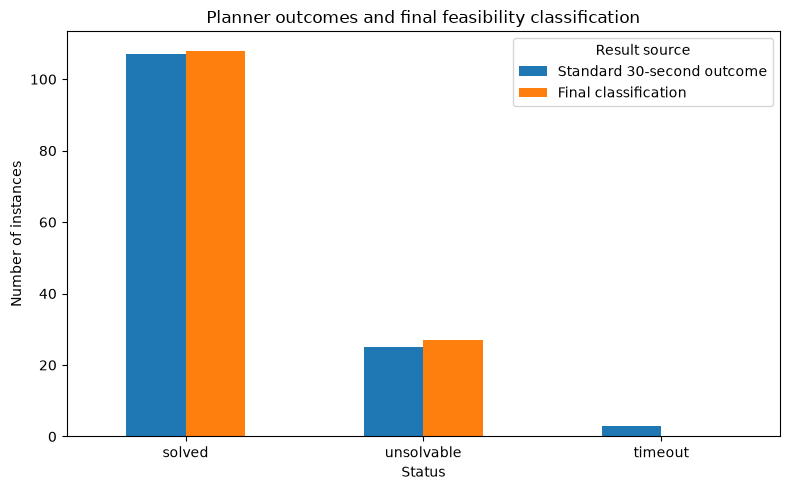

,instance_id,standard_status,standard_runtime_seconds,classification_status,classification_runtime_seconds,plan_makespan
92,rover-battery-n4-mem-low-corr-low-seed-12,timeout,30.107204,unsolvable,73.727800,NaN
94,rover-battery-n4-mem-low-corr-low-seed-14,timeout,30.109172,unsolvable,77.297805,NaN
123,rover-battery-n4-mem-high-corr-low-seed-13,timeout,30.119575,solved,35.325328,23.0


In [4]:
status_table = pd.DataFrame(
    {
        "Standard 30-second outcome": standard_counts,
        "Final classification": (
            classification_counts
            .reindex(STANDARD_STATUS_ORDER, fill_value=0)
        ),
    }
)

display(status_table)

ax = status_table.plot(
    kind="bar",
    figsize=(8, 5),
)
ax.set_title("Planner outcomes and final feasibility classification")
ax.set_xlabel("Status")
ax.set_ylabel("Number of instances")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Result source")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "status_standard_vs_classified.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

extended_cases = classified_df[
    classified_df["classification_source"].eq("extended_120s")
][
    [
        "instance_id",
        "standard_status",
        "standard_runtime_seconds",
        "classification_status",
        "classification_runtime_seconds",
        "plan_makespan",
    ]
].copy()

display(extended_cases)

## 3. Mission feasibility

Feasibility uses `classification_status`, so every instance has a definitive solved or unsolvable outcome. Success rates are reported for the three experimental factors and for the dataset-count × memory interaction.

In [5]:
def summarize_feasibility(
    frame: pd.DataFrame,
    group_columns,
) -> pd.DataFrame:
    """Count classified outcomes and calculate mission success rate."""
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    records = []

    for keys, group in frame.groupby(
        group_columns,
        observed=True,
        sort=False,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        record = dict(zip(group_columns, keys))
        statuses = group["classification_status"].astype(str)

        solved = int(statuses.eq("solved").sum())
        unsolvable = int(statuses.eq("unsolvable").sum())
        total = len(group)

        record.update(
            {
                "instances": total,
                "solved": solved,
                "unsolvable": unsolvable,
                "success_rate": solved / total,
                "success_percent": 100 * solved / total,
            }
        )
        records.append(record)

    return pd.DataFrame(records)


success_by_dataset = summarize_feasibility(
    classified_df,
    "dataset_count",
).sort_values("dataset_count")

success_by_memory = summarize_feasibility(
    classified_df,
    "memory_level",
)

success_by_corruption = summarize_feasibility(
    classified_df,
    "corruption_level",
)

success_dataset_memory = summarize_feasibility(
    classified_df,
    ["dataset_count", "memory_level"],
).sort_values(["dataset_count", "memory_level"])

print("Success by dataset count")
display(success_by_dataset)

print("Success by memory level")
display(success_by_memory)

print("Success by corruption level")
display(success_by_corruption)

print("Dataset-count × memory interaction")
display(success_dataset_memory)

Success by dataset count


,dataset_count,instances,solved,unsolvable,success_rate,success_percent
0,2,45,45,0,1.0,100.0
1,3,45,36,9,0.8,80.0
2,4,45,27,18,0.6,60.0


Success by memory level


,memory_level,instances,solved,unsolvable,success_rate,success_percent
0,low,45,21,24,0.466667,46.666667
1,medium,45,42,3,0.933333,93.333333
2,high,45,45,0,1.000000,100.000000


Success by corruption level


,corruption_level,instances,solved,unsolvable,success_rate,success_percent
0,low,45,36,9,0.8,80.0
1,medium,45,36,9,0.8,80.0
2,high,45,36,9,0.8,80.0


Dataset-count × memory interaction


,dataset_count,memory_level,instances,solved,unsolvable,success_rate,success_percent
2,2,high,15,15,0,1.0,100.0
0,2,low,15,15,0,1.0,100.0
1,2,medium,15,15,0,1.0,100.0
5,3,high,15,15,0,1.0,100.0
3,3,low,15,6,9,0.4,40.0
4,3,medium,15,15,0,1.0,100.0
8,4,high,15,15,0,1.0,100.0
6,4,low,15,0,15,0.0,0.0
7,4,medium,15,12,3,0.8,80.0


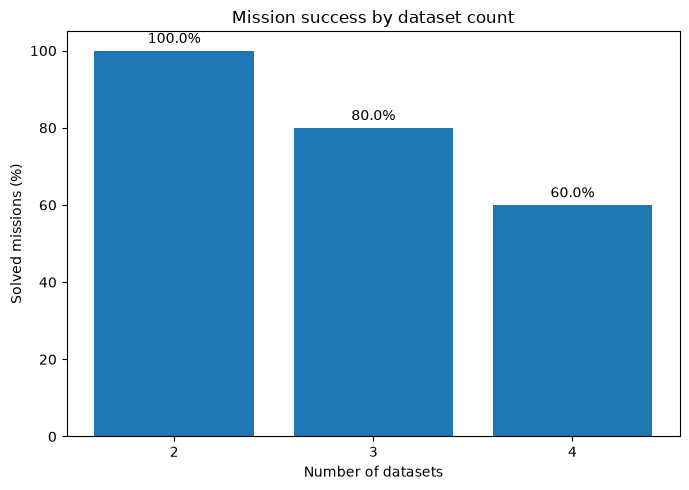

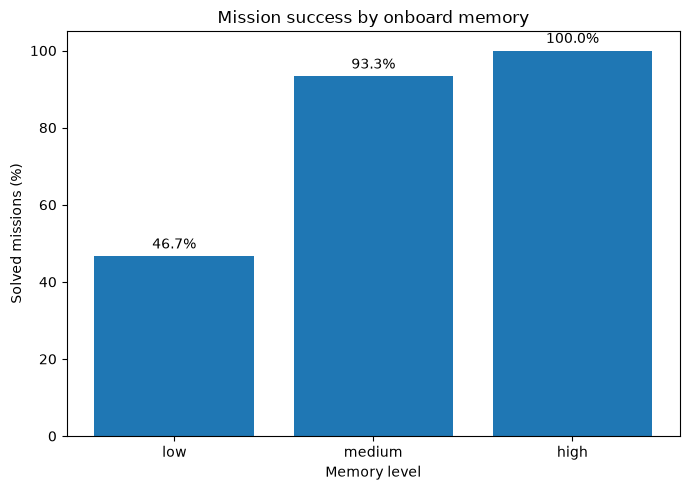

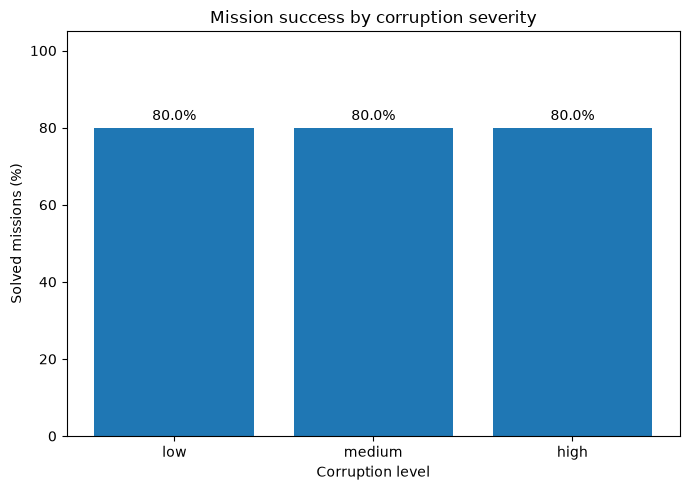

In [6]:
def save_success_bar(
    summary: pd.DataFrame,
    category_column: str,
    title: str,
    xlabel: str,
    filename: str,
    order=None,
) -> None:
    plot_data = summary.copy()

    if order is not None:
        plot_data[category_column] = pd.Categorical(
            plot_data[category_column],
            categories=order,
            ordered=True,
        )
        plot_data = plot_data.sort_values(category_column)

    labels = plot_data[category_column].astype(str)
    values = plot_data["success_percent"]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(labels, values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Solved missions (%)")
    ax.set_ylim(0, 105)

    for index, value in enumerate(values):
        ax.text(
            index,
            min(value + 2, 102),
            f"{value:.1f}%",
            ha="center",
        )

    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


save_success_bar(
    success_by_dataset,
    "dataset_count",
    "Mission success by dataset count",
    "Number of datasets",
    "success_by_dataset_count.png",
    DATASET_ORDER,
)

save_success_bar(
    success_by_memory,
    "memory_level",
    "Mission success by onboard memory",
    "Memory level",
    "success_by_memory.png",
    MEMORY_ORDER,
)

save_success_bar(
    success_by_corruption,
    "corruption_level",
    "Mission success by corruption severity",
    "Corruption level",
    "success_by_corruption.png",
    CORRUPTION_ORDER,
)

dataset_count,2,3,4
memory_level,,,
low,100.0,40.0,0.0
medium,100.0,100.0,80.0
high,100.0,100.0,100.0


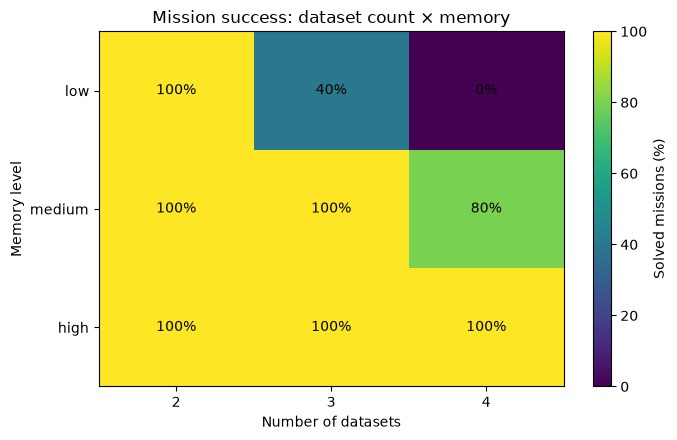

In [7]:
interaction_matrix = (
    success_dataset_memory.pivot(
        index="memory_level",
        columns="dataset_count",
        values="success_percent",
    )
    .reindex(index=MEMORY_ORDER, columns=DATASET_ORDER)
)

display(interaction_matrix)

fig, ax = plt.subplots(figsize=(7, 4.5))
image = ax.imshow(
    interaction_matrix.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=100,
)

ax.set_title("Mission success: dataset count × memory")
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Memory level")
ax.set_xticks(range(len(DATASET_ORDER)))
ax.set_xticklabels(DATASET_ORDER)
ax.set_yticks(range(len(MEMORY_ORDER)))
ax.set_yticklabels(MEMORY_ORDER)

for row_index in range(interaction_matrix.shape[0]):
    for column_index in range(interaction_matrix.shape[1]):
        value = interaction_matrix.iloc[row_index, column_index]
        ax.text(
            column_index,
            row_index,
            f"{value:.0f}%",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Solved missions (%)")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "success_dataset_memory_interaction.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 4. Computational difficulty under the fixed 30-second budget

Runtime analysis uses the original `wall_runtime_seconds` values from the standard experiment. This includes the three timeout runs at approximately the 30-second limit. Extended classification runtimes are excluded from these comparisons.

In [8]:
runtime_df = standard_df.copy()
runtime_df["runtime_30s_seconds"] = runtime_df["wall_runtime_seconds"]

runtime_by_dataset = (
    runtime_df.groupby("dataset_count", observed=True)
    .agg(
        instances=("instance_id", "count"),
        mean_runtime=("runtime_30s_seconds", "mean"),
        median_runtime=("runtime_30s_seconds", "median"),
        p90_runtime=(
            "runtime_30s_seconds",
            lambda values: values.quantile(0.90),
        ),
        maximum_runtime=("runtime_30s_seconds", "max"),
        timeouts=("status", lambda values: values.eq("timeout").sum()),
    )
    .reset_index()
)

runtime_by_corruption = (
    runtime_df.groupby("corruption_level", observed=True)
    .agg(
        instances=("instance_id", "count"),
        mean_runtime=("runtime_30s_seconds", "mean"),
        median_runtime=("runtime_30s_seconds", "median"),
        p90_runtime=(
            "runtime_30s_seconds",
            lambda values: values.quantile(0.90),
        ),
        maximum_runtime=("runtime_30s_seconds", "max"),
        timeouts=("status", lambda values: values.eq("timeout").sum()),
    )
    .reset_index()
)

print("Runtime by dataset count")
display(runtime_by_dataset)

print("Runtime by corruption level")
display(runtime_by_corruption)

Runtime by dataset count


,dataset_count,instances,mean_runtime,median_runtime,p90_runtime,maximum_runtime,timeouts
0,2,45,0.398100,0.383965,0.448662,0.481760,0
1,3,45,0.797414,0.528247,1.754688,3.438560,0
2,4,45,9.357990,7.314771,25.345049,30.119575,3


Runtime by corruption level


,corruption_level,instances,mean_runtime,median_runtime,p90_runtime,maximum_runtime,timeouts
0,low,45,6.252784,0.532860,25.136196,30.119575,3
1,medium,45,3.286430,0.534489,9.471424,28.444092,0
2,high,45,1.014290,0.458232,2.644699,5.286685,0


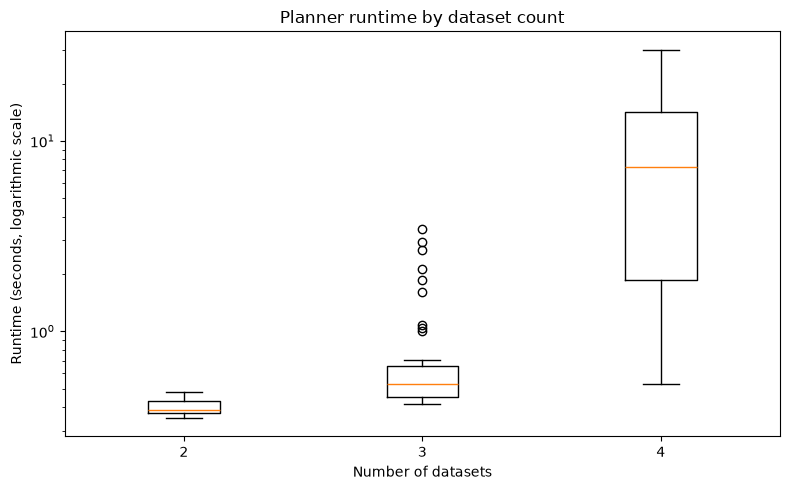

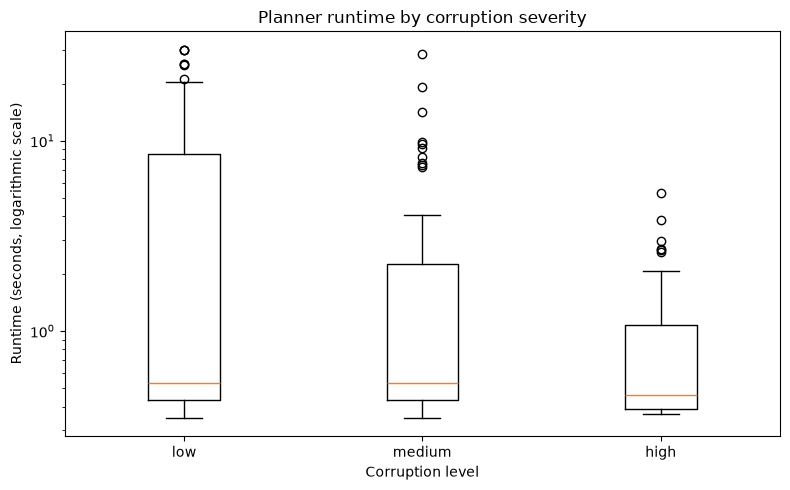

In [9]:
dataset_runtime_groups = [
    runtime_df.loc[
        runtime_df["dataset_count"].eq(dataset_count),
        "runtime_30s_seconds",
    ].dropna()
    for dataset_count in DATASET_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    dataset_runtime_groups,
    tick_labels=[str(value) for value in DATASET_ORDER],
    showfliers=True,
)
ax.set_yscale("log")
ax.set_title("Planner runtime by dataset count")
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Runtime (seconds, logarithmic scale)")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "runtime_by_dataset_count_log.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

corruption_runtime_groups = [
    runtime_df.loc[
        runtime_df["corruption_level"].astype(str).eq(level),
        "runtime_30s_seconds",
    ].dropna()
    for level in CORRUPTION_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    corruption_runtime_groups,
    tick_labels=CORRUPTION_ORDER,
    showfliers=True,
)
ax.set_yscale("log")
ax.set_title("Planner runtime by corruption severity")
ax.set_xlabel("Corruption level")
ax.set_ylabel("Runtime (seconds, logarithmic scale)")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "runtime_by_corruption_log.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 5. Plan efficiency and battery use

Efficiency metrics are available only for solved missions. Comparisons among solved plans therefore describe the plans ENHSP successfully generated; they must not be interpreted as unconditional averages over all missions.

The planner configuration is satisficing rather than optimal, so makespan, action count, and energy use are valid generated-plan metrics but are not guaranteed global optima.

In [10]:
solved_plans = classified_df[
    classified_df["classification_status"].astype(str).eq("solved")
].copy()

plan_metrics_by_memory = (
    solved_plans.groupby("memory_level", observed=True)
    .agg(
        solved_instances=("instance_id", "count"),
        mean_makespan=("plan_makespan", "mean"),
        median_makespan=("plan_makespan", "median"),
        mean_moves=("move_actions", "mean"),
        median_moves=("move_actions", "median"),
        mean_energy_used=("energy_used", "mean"),
        median_energy_used=("energy_used", "median"),
        mean_battery_remaining=("battery_remaining", "mean"),
        median_battery_remaining=("battery_remaining", "median"),
        mean_battery_utilization=(
            "battery_utilization_ratio",
            "mean",
        ),
    )
    .reset_index()
)

plan_metrics_by_dataset = (
    solved_plans.groupby("dataset_count", observed=True)
    .agg(
        solved_instances=("instance_id", "count"),
        mean_makespan=("plan_makespan", "mean"),
        median_makespan=("plan_makespan", "median"),
        mean_moves=("move_actions", "mean"),
        median_moves=("move_actions", "median"),
        mean_energy_used=("energy_used", "mean"),
        median_energy_used=("energy_used", "median"),
        mean_battery_remaining=("battery_remaining", "mean"),
        median_battery_remaining=("battery_remaining", "median"),
    )
    .reset_index()
)

print("Solved-plan metrics by memory")
display(plan_metrics_by_memory)

print("Solved-plan metrics by dataset count")
display(plan_metrics_by_dataset)

Solved-plan metrics by memory


,memory_level,solved_instances,mean_makespan,median_makespan,mean_moves,median_moves,mean_energy_used,median_energy_used,mean_battery_remaining,median_battery_remaining,mean_battery_utilization
0,low,21,25.761905,24.0,7.714286,6.0,24.571429,24.0,15.428571,16.0,0.614286
1,medium,42,28.119048,29.0,8.952381,10.0,30.476190,31.0,9.523810,9.0,0.761905
2,high,45,23.822222,24.0,7.777778,8.0,26.577778,28.0,13.422222,12.0,0.664444


Solved-plan metrics by dataset count


,dataset_count,solved_instances,mean_makespan,median_makespan,mean_moves,median_moves,mean_energy_used,median_energy_used,mean_battery_remaining,median_battery_remaining
0,2,45,19.044444,19.0,5.333333,6.0,18.266667,18.0,21.733333,22.0
1,3,36,30.027778,30.0,9.777778,10.0,31.555556,34.0,8.444444,6.0
2,4,27,31.703704,32.0,10.962963,10.0,38.296296,40.0,1.703704,0.0


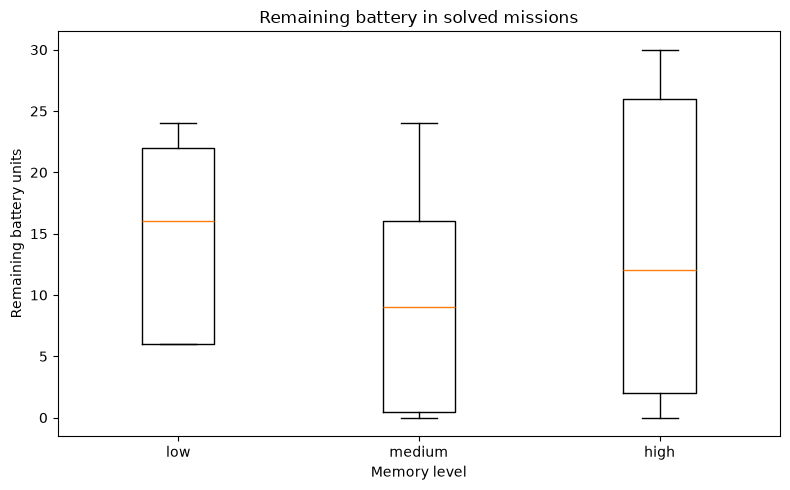

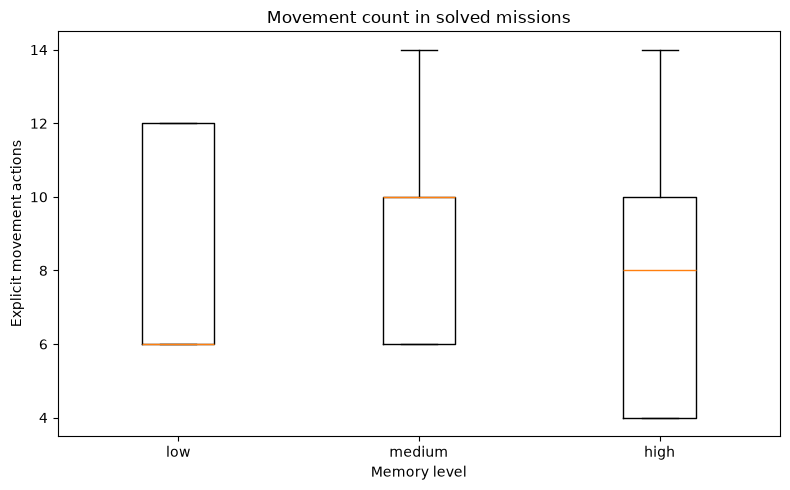

In [11]:
battery_groups = [
    solved_plans.loc[
        solved_plans["memory_level"].astype(str).eq(level),
        "battery_remaining",
    ].dropna()
    for level in MEMORY_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    battery_groups,
    tick_labels=MEMORY_ORDER,
    showfliers=True,
)
ax.set_title("Remaining battery in solved missions")
ax.set_xlabel("Memory level")
ax.set_ylabel("Remaining battery units")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "battery_remaining_by_memory.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

move_groups = [
    solved_plans.loc[
        solved_plans["memory_level"].astype(str).eq(level),
        "move_actions",
    ].dropna()
    for level in MEMORY_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    move_groups,
    tick_labels=MEMORY_ORDER,
    showfliers=True,
)
ax.set_title("Movement count in solved missions")
ax.set_xlabel("Memory level")
ax.set_ylabel("Explicit movement actions")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "move_actions_by_memory.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 6. Exploratory statistical tests

The tests below are exploratory because the experiment uses five unseen seeds and synthetic deterministic missions.

- Chi-square tests examine associations between each experimental factor and final feasibility.
- Kruskal–Wallis tests compare standard planner runtime across factor levels.
- Friedman tests compare memory levels on matched missions where all three memory variants were solved and therefore have complete plan metrics.
- Cramér's V, epsilon-squared, and Kendall's W are reported as effect-size measures.

In [12]:
def cramers_v(contingency_table: pd.DataFrame) -> tuple:
    """Return chi-square results and Cramér's V."""
    chi2, p_value, degrees_freedom, expected = chi2_contingency(
        contingency_table
    )

    sample_size = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape
    denominator = sample_size * min(rows - 1, columns - 1)

    effect_size = (
        np.sqrt(chi2 / denominator)
        if denominator > 0
        else np.nan
    )

    return (
        chi2,
        p_value,
        degrees_freedom,
        expected,
        effect_size,
    )


def epsilon_squared_kruskal(
    statistic: float,
    sample_count: int,
    group_count: int,
) -> float:
    """Exploratory epsilon-squared effect size for Kruskal–Wallis."""
    denominator = sample_count - group_count

    if denominator <= 0:
        return np.nan

    return max(
        0.0,
        (statistic - group_count + 1) / denominator,
    )


statistical_results = []

for factor, order in [
    ("dataset_count", DATASET_ORDER),
    ("memory_level", MEMORY_ORDER),
    ("corruption_level", CORRUPTION_ORDER),
]:
    contingency = pd.crosstab(
        classified_df[factor],
        classified_df["classification_status"],
    ).reindex(
        index=order,
        columns=CLASSIFICATION_STATUS_ORDER,
        fill_value=0,
    )

    print(f"Feasibility contingency table: {factor}")
    display(contingency)

    chi2, p_value, dof, expected, effect_size = cramers_v(
        contingency
    )

    statistical_results.append(
        {
            "analysis": f"Feasibility association: {factor}",
            "test": "Chi-square test of independence",
            "statistic": chi2,
            "p_value": p_value,
            "degrees_of_freedom": dof,
            "effect_size_name": "Cramer's V",
            "effect_size": effect_size,
            "sample_size": int(contingency.to_numpy().sum()),
            "notes": (
                f"Minimum expected count: {expected.min():.3f}"
            ),
        }
    )

for factor, order in [
    ("dataset_count", DATASET_ORDER),
    ("memory_level", MEMORY_ORDER),
    ("corruption_level", CORRUPTION_ORDER),
]:
    samples = [
        runtime_df.loc[
            runtime_df[factor].astype(str).eq(str(level)),
            "runtime_30s_seconds",
        ].dropna()
        for level in order
    ]

    statistic, p_value = kruskal(*samples)
    sample_count = sum(len(sample) for sample in samples)
    effect_size = epsilon_squared_kruskal(
        statistic,
        sample_count,
        len(samples),
    )

    statistical_results.append(
        {
            "analysis": f"Standard runtime difference: {factor}",
            "test": "Kruskal-Wallis",
            "statistic": statistic,
            "p_value": p_value,
            "degrees_of_freedom": len(samples) - 1,
            "effect_size_name": "Epsilon-squared",
            "effect_size": effect_size,
            "sample_size": sample_count,
            "notes": "Includes standard timeout runtimes near 30 seconds.",
        }
    )

statistical_results_df = pd.DataFrame(statistical_results)
display(statistical_results_df)

Feasibility contingency table: dataset_count


classification_status,solved,unsolvable
dataset_count,,
2,45,0
3,36,9
4,27,18


Feasibility contingency table: memory_level


classification_status,solved,unsolvable
memory_level,,
low,21,24
medium,42,3
high,45,0


Feasibility contingency table: corruption_level


classification_status,solved,unsolvable
corruption_level,,
low,36,9
medium,36,9
high,36,9


,analysis,test,statistic,p_value,degrees_of_freedom,effect_size_name,effect_size,sample_size,notes
0,Feasibility association: dataset_count,Chi-square test of independence,22.500000,1.300730e-05,2,Cramer's V,0.408248,135,Minimum expected count: 9.000
1,Feasibility association: memory_level,Chi-square test of independence,47.500000,4.847369e-11,2,Cramer's V,0.593171,135,Minimum expected count: 9.000
2,Feasibility association: corruption_level,Chi-square test of independence,0.000000,1.000000e+00,2,Cramer's V,0.000000,135,Minimum expected count: 9.000
3,Standard runtime difference: dataset_count,Kruskal-Wallis,100.993203,1.173829e-22,2,Epsilon-squared,0.749949,135,Includes standard timeout runtimes near 30 sec...
4,Standard runtime difference: memory_level,Kruskal-Wallis,7.178301,2.762179e-02,2,Epsilon-squared,0.039230,135,Includes standard timeout runtimes near 30 sec...
5,Standard runtime difference: corruption_level,Kruskal-Wallis,4.910414,8.584543e-02,2,Epsilon-squared,0.022049,135,Includes standard timeout runtimes near 30 sec...


In [13]:
def run_matched_memory_test(metric: str) -> dict:
    """Compare memory levels on complete matched solved-mission blocks."""
    pivot = (
        solved_plans.pivot_table(
            index=[
                "dataset_count",
                "corruption_level",
                "seed",
            ],
            columns="memory_level",
            values=metric,
            aggfunc="first",
            observed=True,
        )
        .reindex(columns=MEMORY_ORDER)
        .dropna()
    )

    if len(pivot) < 2:
        return {
            "analysis": f"Matched memory comparison: {metric}",
            "test": "Friedman",
            "statistic": np.nan,
            "p_value": np.nan,
            "degrees_of_freedom": 2,
            "effect_size_name": "Kendall's W",
            "effect_size": np.nan,
            "sample_size": len(pivot),
            "notes": "Insufficient complete matched blocks.",
        }

    statistic, p_value = friedmanchisquare(
        pivot["low"],
        pivot["medium"],
        pivot["high"],
    )

    kendalls_w = statistic / (
        len(pivot) * (len(MEMORY_ORDER) - 1)
    )

    return {
        "analysis": f"Matched memory comparison: {metric}",
        "test": "Friedman",
        "statistic": statistic,
        "p_value": p_value,
        "degrees_of_freedom": 2,
        "effect_size_name": "Kendall's W",
        "effect_size": kendalls_w,
        "sample_size": len(pivot),
        "notes": (
            "Complete matched blocks where low, medium, and high "
            "memory variants were all solved."
        ),
    }


matched_tests = pd.DataFrame(
    [
        run_matched_memory_test("move_actions"),
        run_matched_memory_test("energy_used"),
        run_matched_memory_test("plan_makespan"),
    ]
)

statistical_results_df = pd.concat(
    [statistical_results_df, matched_tests],
    ignore_index=True,
)

display(matched_tests)

,analysis,test,statistic,p_value,degrees_of_freedom,effect_size_name,effect_size,sample_size,notes
0,Matched memory comparison: move_actions,Friedman,35.292308,2.169565e-08,2,Kendall's W,0.840293,21,"Complete matched blocks where low, medium, and..."
1,Matched memory comparison: energy_used,Friedman,35.292308,2.169565e-08,2,Kendall's W,0.840293,21,"Complete matched blocks where low, medium, and..."
2,Matched memory comparison: plan_makespan,Friedman,34.238806,3.673988e-08,2,Kendall's W,0.815210,21,"Complete matched blocks where low, medium, and..."


## 7. Export figures and analysis tables

The exported tables are suitable for selecting values for the IEEE-style paper and presentation. All plots are saved at 300 dpi.

In [14]:
exports = {
    "status_standard_vs_classified.csv": (
        status_table.reset_index().rename(
            columns={"index": "status"}
        )
    ),
    "extended_classifications.csv": extended_cases,
    "success_by_dataset_count.csv": success_by_dataset,
    "success_by_memory.csv": success_by_memory,
    "success_by_corruption.csv": success_by_corruption,
    "success_dataset_memory_interaction.csv": (
        success_dataset_memory
    ),
    "runtime_by_dataset_count.csv": runtime_by_dataset,
    "runtime_by_corruption.csv": runtime_by_corruption,
    "solved_plan_metrics_by_memory.csv": (
        plan_metrics_by_memory
    ),
    "solved_plan_metrics_by_dataset_count.csv": (
        plan_metrics_by_dataset
    ),
    "statistical_tests.csv": statistical_results_df,
}

for filename, table in exports.items():
    table.to_csv(
        TABLE_DIR / filename,
        index=False,
    )

print(f"Exported {len(exports)} analysis tables.")
print(f"Generated {len(list(PLOT_DIR.glob('*.png')))} plot files.")
print("Notebook analysis exports completed.")

Exported 11 analysis tables.
Generated 9 plot files.
Notebook analysis exports completed.


## 8. Results interpretation

The following summary is generated directly from the final result tables so that the narrative remains consistent with the data.

In [17]:
dataset_success_text = ", ".join(
    f"{int(row.dataset_count)} datasets: "
    f"{row.success_percent:.1f}%"
    for row in success_by_dataset.itertuples()
)

memory_success_text = ", ".join(
    f"{row.memory_level}: {row.success_percent:.1f}%"
    for row in success_by_memory.itertuples()
)

corruption_success_text = ", ".join(
    f"{row.corruption_level}: {row.success_percent:.1f}%"
    for row in success_by_corruption.itertuples()
)

timeout_rows = classified_df[
    classified_df["standard_status"].astype(str).eq("timeout")
]

timeout_corruptions = sorted(
    timeout_rows["corruption_level"].astype(str).unique()
)

timeout_description = (
    ", ".join(timeout_corruptions)
    if timeout_corruptions
    else "none"
)

summary_markdown = f"""
### Main findings

1. **Mission size reduced feasibility.** Final success rates were {dataset_success_text}.
2. **Onboard memory improved feasibility.** Final success rates by memory were {memory_success_text}. The dataset-count × memory table shows where this benefit was strongest.
3. **Corruption severity affected the planning problem differently from memory and mission size.** Final success rates were {corruption_success_text}; runtime plots and tests should be consulted before claiming a strong feasibility effect.
4. **Computational difficulty was concentrated near the hardest boundary cases.** Three of 135 standard runs timed out at 30 seconds. Their corruption levels were: {timeout_description}. All three were resolved by the selective 120-second classification runs.
5. **Every classified solved plan respected the battery and route checks.** No generated instance contained an individually unsafe dataset, so failures arose from the combined mission constraints rather than from a dataset that was impossible at initialization.

### Interpretation limits

- The study uses five unseen seeds, a synthetic linear map, one PDDL+ model, and one ENHSP configuration.
- Movement is the only action that consumes battery in the current model.
- Terrain, dataset sizes, encoding durations, and corruption margins are deterministic once a seed is fixed.
- The planner is satisficing, so generated-plan efficiency metrics are not guaranteed to be globally optimal.
- Standard runtime includes Java and planner startup overhead.
- Statistical tests are exploratory and should be reported together with effect sizes and descriptive results.
"""

display(Markdown(summary_markdown))


### Main findings

1. **Mission size reduced feasibility.** Final success rates were 2 datasets: 100.0%, 3 datasets: 80.0%, 4 datasets: 60.0%.
2. **Onboard memory improved feasibility.** Final success rates by memory were low: 46.7%, medium: 93.3%, high: 100.0%. The dataset-count × memory table shows where this benefit was strongest.
3. **Corruption severity affected the planning problem differently from memory and mission size.** Final success rates were low: 80.0%, medium: 80.0%, high: 80.0%; runtime plots and tests should be consulted before claiming a strong feasibility effect.
4. **Computational difficulty was concentrated near the hardest boundary cases.** Three of 135 standard runs timed out at 30 seconds. Their corruption levels were: low. All three were resolved by the selective 120-second classification runs.
5. **Every classified solved plan respected the battery and route checks.** No generated instance contained an individually unsafe dataset, so failures arose from the combined mission constraints rather than from a dataset that was impossible at initialization.

### Interpretation limits

- The study uses five unseen seeds, a synthetic linear map, one PDDL+ model, and one ENHSP configuration.
- Movement is the only action that consumes battery in the current model.
- Terrain, dataset sizes, encoding durations, and corruption margins are deterministic once a seed is fixed.
- The planner is satisficing, so generated-plan efficiency metrics are not guaranteed to be globally optimal.
- Standard runtime includes Java and planner startup overhead.
- Statistical tests are exploratory and should be reported together with effect sizes and descriptive results.


## 9. Reproducibility record

The main statistical analysis uses only the frozen final experiment:

- Results: `experiments/results/battery_final_unseen.csv`
- Final feasibility classification: `experiments/results/battery_final_unseen_classified.csv`
- Seeds: 10–14
- Standard timeout: 30 seconds
- Selective classification timeout: 120 seconds
- Planner configuration: `sat-hadd`
- Fixed battery capacity: 40 energy units

Calibration seeds 0–4 were used to select and validate the model design, but they are not mixed into the final statistical results presented in this notebook.